In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

TICKERS = ["TSLA", "BND", "SPY"]
START = "2015-01-01"
END = "2026-06-30"

In [ ]:
import yfinance as yf

def fetch_data(tickers, start, end):
    data = {}
    for t in tickers:
        df = yf.download(t, start=start, end=end, auto_adjust=False, progress=False)
        if df.empty: # type: ignore
            raise ValueError(f"No data returned for {t}")
        df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns # type: ignore
        data[t] = df
    return data

raw_data = fetch_data(TICKERS, START, END)

for t in TICKERS:
    print(f"{t}: {raw_data[t].shape[0]} rows, {raw_data[t].index.min().date()} -> {raw_data[t].index.max().date()}")

TSLA: 2888 rows, 2015-01-02 -> 2026-06-29
BND: 2888 rows, 2015-01-02 -> 2026-06-29
SPY: 2888 rows, 2015-01-02 -> 2026-06-29


In [3]:
import os
os.makedirs("../data/raw", exist_ok=True)
for t in TICKERS:
    raw_data[t].to_csv(f"../data/raw/{t}_raw.csv")
print("Raw data saved.")

Raw data saved.


In [4]:
long_frames = []
for t in TICKERS:
    df = raw_data[t].copy()
    df["Ticker"] = t
    long_frames.append(df)
combined_long = pd.concat(long_frames).reset_index().rename(columns={"index": "Date"})
combined_long.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000,TSLA
1,2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500,TSLA
2,2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,TSLA
3,2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,TSLA
4,2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,TSLA


In [5]:
for t in TICKERS:
    print(f"\n--- {t} describe() ---")
    print(raw_data[t].describe().round(2))

print("\nDtypes:")
print(combined_long.dtypes)


--- TSLA describe() ---
Price  Adj Close    Close     High      Low     Open        Volume
count    2888.00  2888.00  2888.00  2888.00  2888.00  2.888000e+03
mean      148.77   148.77   151.99   145.42   148.80  1.087922e+08
std       138.90   138.90   141.85   135.87   138.98  7.082549e+07
min         9.58     9.58    10.33     9.40     9.49  1.062000e+07
25%        18.39    18.39    18.67    18.02    18.39  6.548325e+07
50%       133.44   133.44   136.05   125.83   131.50  9.033615e+07
75%       251.93   251.93   257.49   245.83   251.68  1.261204e+08
max       489.88   489.88   498.83   485.33   489.88  9.140820e+08

--- BND describe() ---
Price  Adj Close    Close     High      Low     Open       Volume
count    2888.00  2888.00  2888.00  2888.00  2888.00      2888.00
mean       66.50    79.33    79.44    79.21    79.33   4653785.80
std         4.71     5.31     5.30     5.32     5.31   3017703.95
min        58.73    68.04    68.38    67.99    68.08         0.00
25%        62.48  

In [6]:
print("Missing values per asset:")
for t in TICKERS:
    missing = raw_data[t].isna().sum()
    print(f"\n{t}:\n{missing[missing > 0] if missing.sum() else 'No missing values'}")

full_bdays = pd.bdate_range(start=START, end=END)
for t in TICKERS:
    raw_data[t] = raw_data[t].reindex(full_bdays).ffill().dropna()

print("\nAfter reindexing + forward-fill:")
for t in TICKERS:
    print(f"{t}: {raw_data[t].isna().sum().sum()} missing values remaining")

Missing values per asset:

TSLA:
No missing values

BND:
No missing values

SPY:
No missing values

After reindexing + forward-fill:
TSLA: 0 missing values remaining
BND: 0 missing values remaining
SPY: 0 missing values remaining


In [7]:
os.makedirs("../data/processed", exist_ok=True)
for t in TICKERS:
    raw_data[t].to_csv(f"../data/processed/{t}_cleaned.csv")
print("Processed data saved.")

Processed data saved.


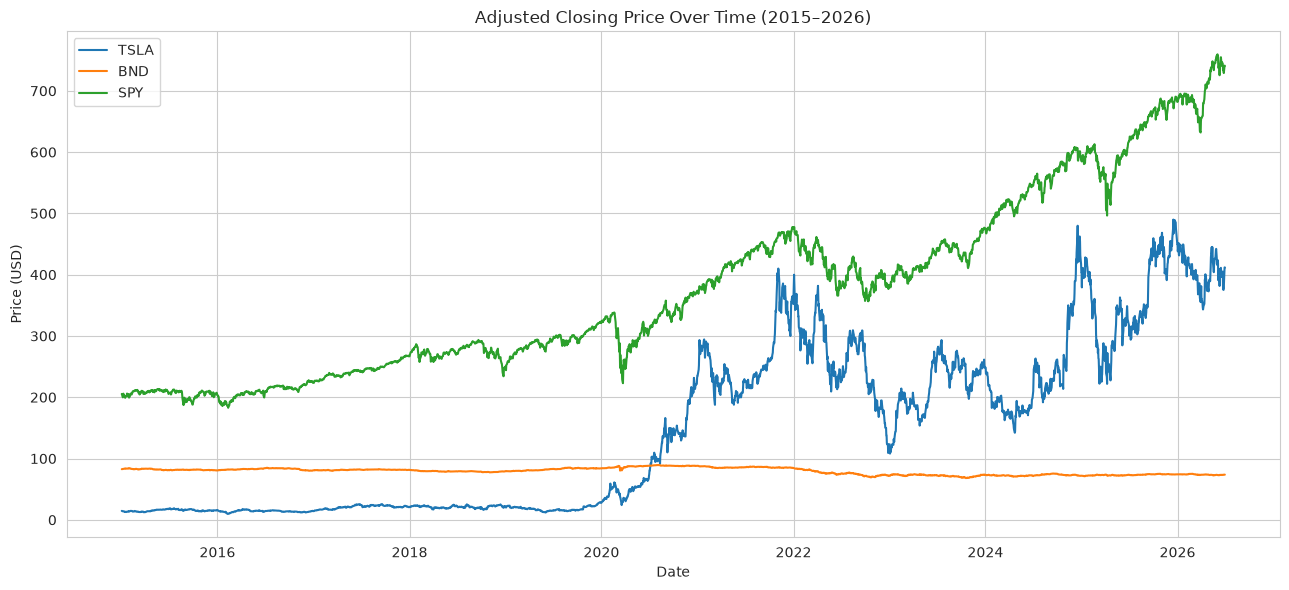

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))
for t in TICKERS:
    ax.plot(raw_data[t].index, raw_data[t]["Close"], label=t)
ax.set_title("Adjusted Closing Price Over Time (2015–2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_closing_price.png", dpi=120)
plt.show()

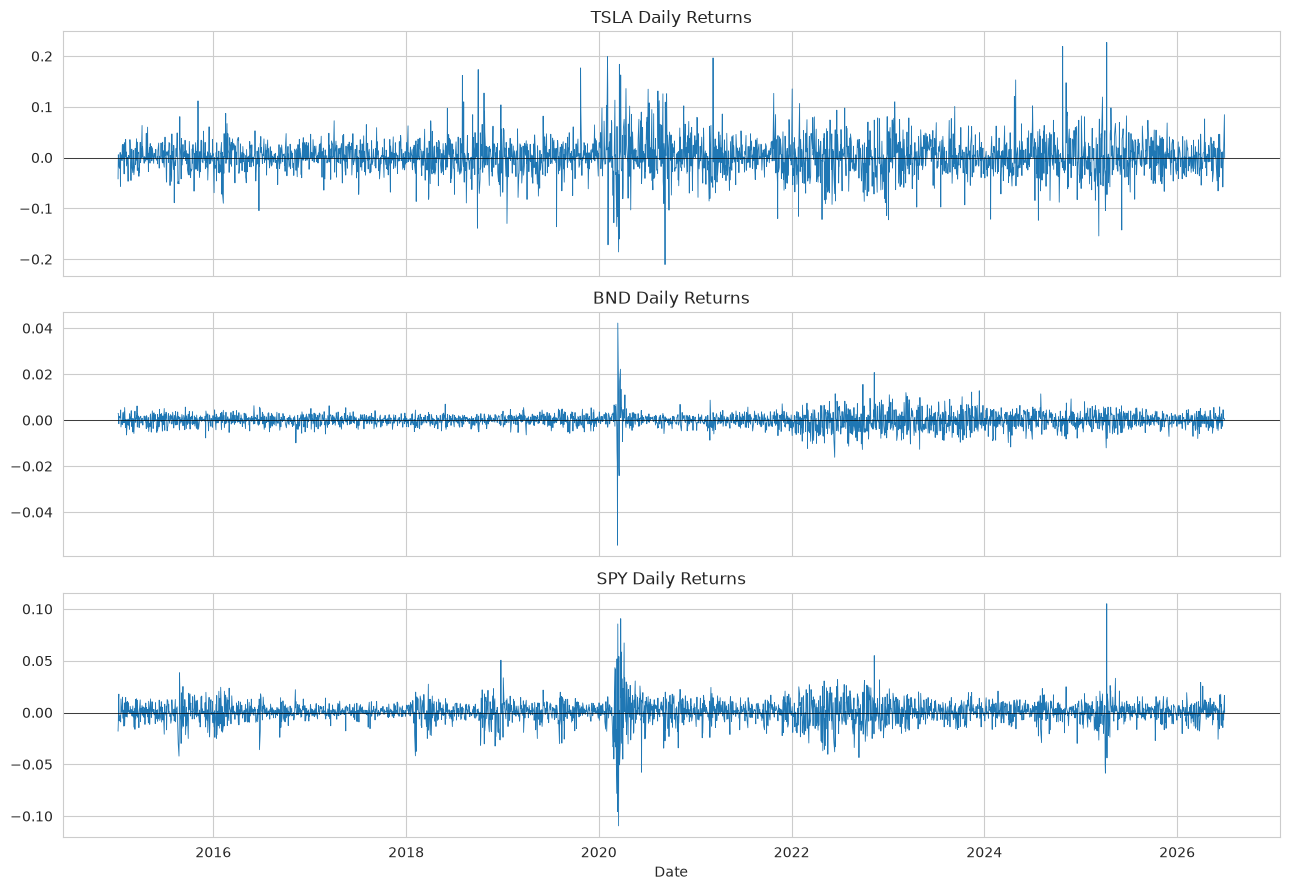

In [9]:
returns = pd.DataFrame({t: raw_data[t]["Close"].pct_change() for t in TICKERS}).dropna()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, t in zip(axes, TICKERS):
    ax.plot(returns.index, returns[t], linewidth=0.6)
    ax.set_title(f"{t} Daily Returns")
    ax.axhline(0, color="black", linewidth=0.5)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("../data/processed/fig_daily_returns.png", dpi=120)
plt.show()

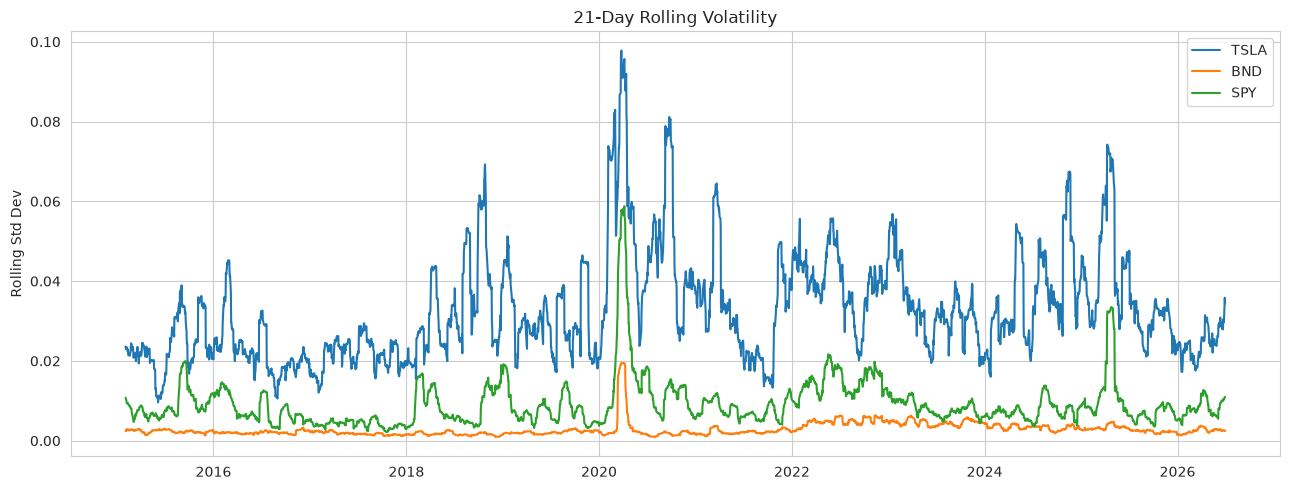

In [10]:
rolling_std = returns.rolling(21).std()

fig, ax = plt.subplots(figsize=(13, 5))
for t in TICKERS:
    ax.plot(rolling_std.index, rolling_std[t], label=t)
ax.set_title("21-Day Rolling Volatility")
ax.set_ylabel("Rolling Std Dev")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_rolling_volatility.png", dpi=120)
plt.show()

In [ ]:
for t in TICKERS:
    mu, sigma = returns[t].mean(), returns[t].std()
    outliers = returns[(returns[t] - mu).abs() > 3 * sigma][t]
    print(f"{t}: {len(outliers)} outlier days (>3 std from mean)")

for t in TICKERS:
    print(f"\n{t} — best day: {returns[t].idxmax().date()} ({returns[t].max():.2%}), " # type: ignore
          f"worst day: {returns[t].idxmin().date()} ({returns[t].min():.2%})") # type: ignore

TSLA: 50 outlier days (>3 std from mean)
BND: 33 outlier days (>3 std from mean)
SPY: 42 outlier days (>3 std from mean)

TSLA — best day: 2025-04-09 (22.69%), worst day: 2020-09-08 (-21.06%)

BND — best day: 2020-03-13 (4.22%), worst day: 2020-03-12 (-5.44%)

SPY — best day: 2025-04-09 (10.50%), worst day: 2020-03-16 (-10.94%)


In [12]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    for key, val in result[4].items():
        print(f"Critical Value ({key}): {val:.4f}")
    verdict = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"Verdict (alpha=0.05): {verdict}\n")

for t in TICKERS:
    adf_report(raw_data[t]["Close"], f"{t} Close Price")
    adf_report(returns[t], f"{t} Daily Return")

--- ADF Test: TSLA Close Price ---
ADF Statistic: -1.0255
p-value:       0.7439
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
Verdict (alpha=0.05): NON-STATIONARY

--- ADF Test: TSLA Daily Return ---
ADF Statistic: -55.2109
p-value:       0.0000
Critical Value (1%): -3.4325
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
Verdict (alpha=0.05): STATIONARY

--- ADF Test: BND Close Price ---
ADF Statistic: -1.0815
p-value:       0.7224
Critical Value (1%): -3.4325
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
Verdict (alpha=0.05): NON-STATIONARY

--- ADF Test: BND Daily Return ---
ADF Statistic: -21.3813
p-value:       0.0000
Critical Value (1%): -3.4325
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
Verdict (alpha=0.05): STATIONARY

--- ADF Test: SPY Close Price ---
ADF Statistic: 1.1744
p-value:       0.9958
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
Verdict (alpha=0